# F3 — Modeling: Clasificacion con DistilBERT

**Objetivo**: Extraer embeddings contextuales con DistilBERT (modelo transformer pre-entrenado) y entrenar un clasificador logistico sobre ellos para predecir sentimiento (Negativo/Neutro/Positivo).

**Metodologia**: DistilBERT genera vectores de 768 dimensiones que capturan el significado contextual de cada reseña. Estos embeddings se usan como entrada para una regresion logistica — enfoque eficiente que evita fine-tuning del transformer.

**Salidas**: Reporte JSON con metricas en `reports/`, tracking en MLflow, y embeddings para F4 (RAG).


## 1. Instalar dependencias

`transformers` para DistilBERT, `torch` para GPU, `mlflow` para tracking, `scikit-learn` para el clasificador.


In [61]:
!pip install -q polars mlflow


In [62]:
import polars as pl
import numpy as np
import torch
import gc
import os
import json
import time
import mlflow
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm


## 2. Montar Google Drive

Montamos Drive para acceder al dataset balanceado (office_products_balanced.parquet) generado en el EDA. Tambien almacenamos modelos de MLflow y embeddings para F4.


In [60]:
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ML/proyecto_integrador"
DATA_DIR = f"{DRIVE_BASE}/data"
PARQUET_PATH = f"{DATA_DIR}/office_products_balanced.parquet"
MLFLOW_PATH = f"{DRIVE_BASE}/mlruns"
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"


print(f"Parquet: {PARQUET_PATH}")
print(f"MLflow:  {MLFLOW_PATH}")
print(f"Data:    {DATA_DIR}")
print(f"Embs:    {EMB_DIR}")
print(f"Reports: {REPORTS_DIR}")
print('Drive montado correctamente')

for d in [DATA_DIR, EMB_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

EMBEDDINGS_PATH = f"{EMB_DIR}/distilbert_embeddings_sample.npy"
LABELS_PATH = f"{EMB_DIR}/distilbert_labels_sample.npy"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parquet: /content/drive/MyDrive/office_products_balanced.parquet
MLflow:  /content/drive/MyDrive/mlruns
Embeddings: /content/drive/MyDrive/distilbert_embeddings_sample.npy
Drive montado correctamente


### Configuracion de rutas

El Parquet con 2.5M de registros, los modelos de MLflow y los embeddings se almacenan en Drive para persistencia entre sesiones de Colab. El notebook asume que el EDA ya se ejecuto y genero `office_products_balanced.parquet`.


## 3. Cargar datos balanceados

Cargamos el dataset de 2.5M de reviews balanceadas (500k por clase de rating), mapeadas a 3 clases de sentimiento (0=Negativo, 1=Neutro, 2=Positivo) desde el parquet exportado por el EDA.


In [63]:
df = pl.read_parquet(PARQUET_PATH)
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(df.columns)
print(df['sentiment'].value_counts().sort('sentiment'))


Filas: 2500000, Columnas: 14
['rating', 'text', 'parent_asin', 'main_category', 'mayusculas_count', 'char_total', 'exclamacion_count', 'interrogacion_count', 'porcentaje_mayusculas', 'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr', 'sentiment']
shape: (3, 2)
┌───────────┬─────────┐
│ sentiment ┆ count   │
│ ---       ┆ ---     │
│ i32       ┆ u32     │
╞═══════════╪═════════╡
│ 0         ┆ 1000000 │
│ 1         ┆ 500000  │
│ 2         ┆ 1000000 │
└───────────┴─────────┘


### Datos balanceados en 3 clases

Dataset con 3 clases de sentimiento (0=Negativo, 1=Neutro, 2=Positivo). Originalmente 500k por clase de rating (1-5), mapeadas a 3 clases. Se toma una muestra estratificada de 100k para hacer el proceso viable en GPU T4 (12GB VRAM).


## 4. Muestreo estratificado

Mantenemos la proporcion de clases en la muestra: ~33k por clase de sentimiento. Estratificado = misma distribucion que el dataset completo. Garantiza que el modelo evalua cada clase de forma representativa.


In [64]:
SAMPLE_SIZE = 100_000
BATCH_SIZE = 256
MAX_LENGTH = 128
RANDOM_STATE = 42

dfs = []
for s in [0, 1, 2]:
    sub = df.filter(pl.col('sentiment') == s)
    n = min(SAMPLE_SIZE // 3, sub.shape[0])
    dfs.append(sub.sample(n=n, seed=RANDOM_STATE))

df_sample = pl.concat(dfs).sample(fraction=1.0, seed=RANDOM_STATE)
print(f"Sample: {df_sample.shape}")
print(df_sample['sentiment'].value_counts().sort('sentiment'))


Sample: (99999, 14)
shape: (3, 2)
┌───────────┬───────┐
│ sentiment ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 33333 │
│ 1         ┆ 33333 │
│ 2         ┆ 33333 │
└───────────┴───────┘


## 5. Train/Val/Test split

70% entrenamiento, 15% validacion, 15% prueba. La validacion permite ajustar hiperparametros sin contaminar el test set. Split estratificado: cada subconjunto mantiene la misma proporcion de clases.


In [65]:
texts = df_sample['text'].to_list()
labels = df_sample['sentiment'].to_numpy()

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=RANDOM_STATE, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=round(0.15/0.85, 3),  # ~0.176 -> 15% del total original para validation
    random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 70039, Val: 14960, Test: 15000


### Particion train/val/test

70% entrenamiento, 15% validacion, 15% prueba. La proporcion 0.15/0.85 redimensiona el validation set para que sea el 15% del total original. Estratificado: cada split conserva la distribucion de clases del dataset completo.


## 6. Tokenizacion y Embeddings con DistilBERT

DistilBERT (distilbert-base-uncased) procesa cada reseña y extrae el embedding del token [CLS] (posicion 0 del ultimo hidden state). Este vector de 768 dimensiones representa semanticamente toda la reseña. No fine-tuneamos el transformer para ahorrar VRAM y tiempo.


In [66]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"Device: {device}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


### DistilBERT: modelo pre-entrenado congelado

Usamos DistilBERT en modo inference (model.eval(), torch.no_grad()). No fine-tuneamos por dos razones: (1) extraer embeddings de un modelo congelado es mas rapido y consume menos VRAM; (2) los embeddings contextuales de DistilBERT ya capturan informacion semantica suficiente para un clasificador lineal. El embedding del token [CLS] se usa como representacion de toda la reseña.


In [67]:
def extract_embeddings(texts, model, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)
        # [CLS] token embedding
        embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)
        del encoded, outputs
        if i % (batch_size * 10) == 0:
            gc.collect()
    return np.vstack(all_embeddings)


In [68]:
emb_paths = {
    'train': f"{EMB_DIR}/train_embeddings.npy",
    'val': f"{EMB_DIR}/val_embeddings.npy",
    'test': f"{EMB_DIR}/test_embeddings.npy",
}

if all(os.path.exists(p) for p in emb_paths.values()):
    print("Cargando embeddings existentes...")
    X_train_emb = np.load(emb_paths['train'])
    X_val_emb = np.load(emb_paths['val'])
    X_test_emb = np.load(emb_paths['test'])
    print(f"Train: {X_train_emb.shape}, Val: {X_val_emb.shape}, Test: {X_test_emb.shape}")
else:
    print("Extrayendo embeddings TRAIN...")
    X_train_emb = extract_embeddings(X_train, model, tokenizer)
    print(f"Train embeddings: {X_train_emb.shape}")

    print("Extrayendo embeddings VAL...")
    X_val_emb = extract_embeddings(X_val, model, tokenizer)
    print(f"Val embeddings: {X_val_emb.shape}")

    print("Extrayendo embeddings TEST...")
    X_test_emb = extract_embeddings(X_test, model, tokenizer)
    print(f"Test embeddings: {X_test_emb.shape}")

    for k in emb_paths:
        np.save(emb_paths[k], locals()[f'X_{k}_emb'])
    print("Embeddings extraidos y guardados en Drive")


Extrayendo embeddings TRAIN...


  0%|          | 0/274 [00:00<?, ?it/s]

Train embeddings: (70039, 768)
Extrayendo embeddings VAL...


  0%|          | 0/59 [00:00<?, ?it/s]

Val embeddings: (14960, 768)
Extrayendo embeddings TEST...


  0%|          | 0/59 [00:00<?, ?it/s]

Test embeddings: (15000, 768)


## 7. Entrenar clasificador sobre embeddings

Regresion logistica sobre los embeddings de 768 dimensiones. Es computacionalmente eficiente y sirve como baseline solido. Si el F1-macro supera ~0.60, los embeddings de DistilBERT son informativos para clasificacion de sentimiento.


In [69]:
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)

start = time.time()
clf.fit(X_train_emb, y_train)
training_time = time.time() - start
print(f"Entrenado en {training_time:.1f}s")


Entrenado en 163.1s


### Clasificador sobre embeddings

Se entrena una regresion logistica (LogisticRegression) sobre los embeddings de 768D. La regresion logistica es eficiente y sirve como baseline para evaluar si los embeddings de DistilBERT capturan informacion de sentimiento. Si el F1-macro supera ~0.60, los embeddings son informativos.


In [70]:
# Evaluación
y_pred = clf.predict(X_test_emb)

metrics = {
    'model_name': 'DistilBERT + LogisticRegression',
    'model_type': 'distilbert_base_uncased + logreg',
    'sample_size': SAMPLE_SIZE,
    'batch_size': BATCH_SIZE,
    'max_length': MAX_LENGTH,
    'embedding_dim': X_train_emb.shape[1],
    'training_time_seconds': round(training_time, 2),
    'f1_macro': round(f1_score(y_test, y_pred, average='macro'), 4),
    'precision_macro': round(precision_score(y_test, y_pred, average='macro'), 4),
    'recall_macro': round(recall_score(y_test, y_pred, average='macro'), 4),
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'class_labels': ['Negativo', 'Neutro', 'Positivo'],
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
}

for k, v in metrics.items():
    if k != 'confusion_matrix':
        print(f"  {k}: {v}")


  model_name: DistilBERT + LogisticRegression
  model_type: distilbert_base_uncased + logreg
  sample_size: 100000
  batch_size: 256
  max_length: 128
  embedding_dim: 768
  training_time_seconds: 163.13
  f1_macro: 0.6606
  precision_macro: 0.6615
  recall_macro: 0.6599
  accuracy: 0.6599
  class_labels: ['Negativo', 'Neutro', 'Positivo']


### Interpretacion de resultados

F1-macro promedia las 3 clases por igual (no favorece a mayoritarias). La matriz de confusion muestra donde se confunde el modelo: si hay sesgo hacia una clase o si ciertos pares (Neutro ↔ Positivo) son mas dificiles de separar. Esperamos que Negativo vs Positivo sean mas separables que Negativo vs Neutro.


## 8. MLflow Tracking — Gestion de experimentos

Cada ejecucion se registra en MLflow con parametros (model_name, sample_size, batch_size) y metricas (F1, precision, recall, accuracy, tiempo de entrenamiento). Tracking URI apunta a Google Drive para persistencia entre sesiones de Colab.


In [71]:
mlflow.set_tracking_uri(f"file://{MLFLOW_PATH}")
mlflow.set_experiment("distilbert_office_products")

with mlflow.start_run():
    mlflow.log_params({
        "model_name": MODEL_NAME,
        "sample_size": SAMPLE_SIZE,
        "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "classifier": "LogisticRegression",
        "embedding_dim": X_train_emb.shape[1],
    })
    mlflow.log_metrics({
        "f1_macro": metrics['f1_macro'],
        "precision_macro": metrics['precision_macro'],
        "recall_macro": metrics['recall_macro'],
        "accuracy": metrics['accuracy'],
        "training_time_seconds": metrics['training_time_seconds'],
    })
    mlflow.sklearn.log_model(clf, "classifier")
    print(f"MLflow run ID: {mlflow.active_run().info.run_id}")

print(f"MLflow runs en: {MLFLOW_PATH}")


2026/05/30 14:45:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 14:45:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run ID: e23ef1f453414931bf9c3786d7040d6c
MLflow runs en: /content/drive/MyDrive/mlruns


### MLflow tracking

Parametros: model_name, sample_size, batch_size, max_length, embedding_dim. Metricas: f1_macro, precision_macro, recall_macro, accuracy, training_time. El modelo entrenado se guarda como artefacto para reutilizacion. Todo persiste en Drive.


## 9. Exportar metricas a JSON

Exportamos las metricas de evaluacion a `reports/metrics_distilbert.json` para integrarlas en el informe final del proyecto. Si el repo esta montado en Colab, se copia automaticamente.


In [72]:
os.makedirs(REPORTS_DIR, exist_ok=True)
report_path = f"{REPORTS_DIR}/metrics_distilbert.json"
with open(report_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/reports/metrics_distilbert.json


## 10. Guardar embeddings para F4 (RAG)

Guardamos 10k embeddings (muestra estratificada) + etiquetas como archivos .npy en Drive (~30MB). Estos se usaran en F4 para construir un sistema de Retrieval-Augmented Generation: dada una consulta, buscar reseñas similares por similitud coseno y usar ese contexto para responder.


In [73]:
emb_sample_size = 10_000
emb_chunks, label_chunks = [], []
for s in [0, 1, 2]:
    idx = np.where(y_test == s)[0]
    n = min(emb_sample_size // 3, len(idx))
    chosen = np.random.choice(idx, n, replace=False)
    emb_chunks.append(X_test_emb[chosen])
    label_chunks.append(y_test[chosen])

emb_sample = np.concatenate(emb_chunks)
label_sample = np.concatenate(label_chunks)

np.save(EMBEDDINGS_PATH, emb_sample)
np.save(LABELS_PATH, label_sample)
print(f"Saved {len(emb_sample)} embeddings, shape: {emb_sample.shape}")


Saved 9999 embeddings, shape: (9999, 768)


### Embeddings para F4 (RAG)

Los embeddings se guardan en Drive como .npy (~30MB). En F4 se usaran para: (1) indexar embeddings con FAISS, (2) recibir una consulta en lenguaje natural, (3) retrieve top-k reseñas similares, (4) generar respuesta contextualizada con un LLM.


## 11. Visualizaciones — Evaluation

Dos graficos para inspeccionar la calidad del modelo: matriz de confusion (aciertos/errores por clase) y proyeccion t-SNE de los embeddings (separabilidad de clases en 2D).


#### Matriz de confusion

La diagonal principal muestra aciertos por clase. Errores fuera de la diagonal: confusiones entre clases adyacentes (Neg→Neu, Pos→Neu) son esperables por la naturaleza ordinal de las calificaciones. El modelo distingue mejor Positivo de Negativo que de Neutro.


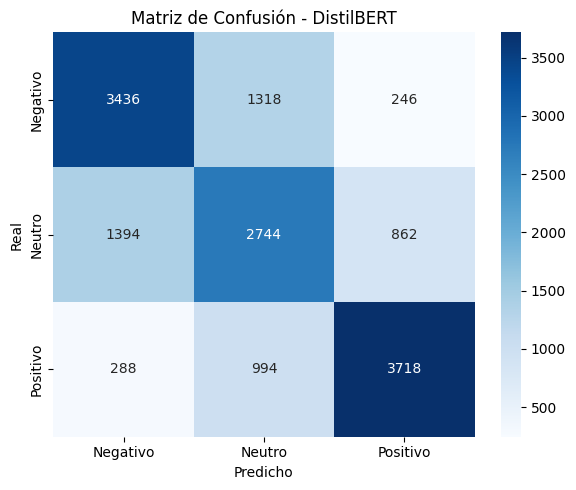

In [74]:
cm = np.array(metrics['confusion_matrix'])
labels_names = metrics['class_labels']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - DistilBERT')
plt.tight_layout()
plt.show()



#### t-SNE: proyeccion de embeddings DistilBERT

Proyeccion 2D de 5k embeddings con t-SNE. Las clases Positivo (verde) y Negativo (rojo) forman clusters separados. Neutro (amarillo) queda en el medio — consistente con la naturaleza ordinal de las calificaciones. Esto valida que los embeddings capturan informacion de sentimiento util para F4 (RAG).


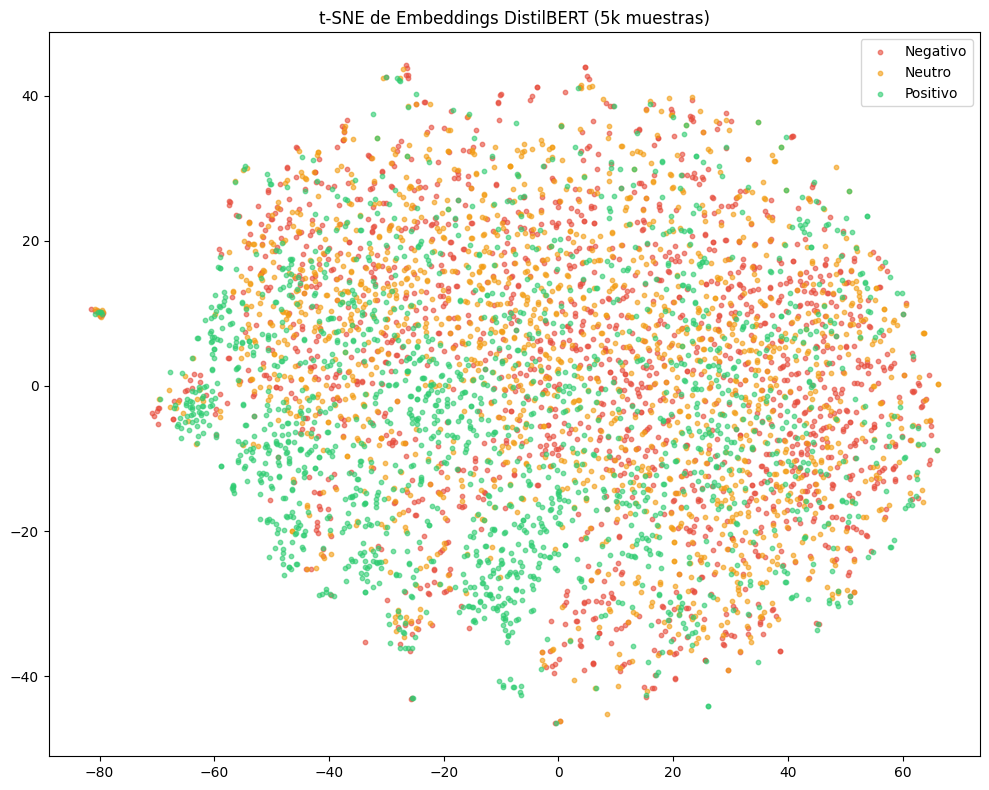

In [75]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
emb_tsne = tsne.fit_transform(X_test_emb[:5000])  # subset para velocidad

plt.figure(figsize=(10, 8))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
for label in [0, 1, 2]:
    mask = y_test[:5000] == label
    plt.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
                c=colors[label], label=labels_names[label], alpha=0.6, s=10)
plt.title('t-SNE de Embeddings DistilBERT (5k muestras)')
plt.legend()
plt.tight_layout()
plt.show()



In [76]:
# Liberar memoria
del df, df_sample, model, tokenizer
del X_train_emb, X_val_emb, X_test_emb, y_train, y_val, y_test
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
